In [15]:
# Trainings Pipeline: Unwetterwarnung mit Open-Meteo API

In [16]:
# Feature Group laden
import os
from pathlib import Path

import hopsworks
import pandas as pd
import numpy as np
from dotenv import load_dotenv

project_root = Path.cwd().resolve()
if not (project_root / ".env").exists():
    project_root = project_root.parent
load_dotenv(project_root / ".env")

api_key = os.getenv("HOPSWORKS_API_KEY")
project_name = os.getenv("HOPSWORKS_PROJECT_NAME")
if not api_key or not project_name:
    raise ValueError("HOPSWORKS_API_KEY und HOPSWORKS_PROJECT_NAME müssen gesetzt sein.")

project = hopsworks.login(
    api_key_value=api_key,
    project=project_name,
    host="eu-west.cloud.hopsworks.ai",
    port=443,
)
fs = project.get_feature_store()

weather_fg = fs.get_feature_group(
    name="weather_features_batch",
    version=1,
)

if weather_fg is None:
    raise RuntimeError("Die Feature Group weather_features_batch wurde nicht gefunden.")

print(f"✅ Feature Group geladen: {weather_fg.name} (v{weather_fg.version})")
print(f"📊 Anzahl Features: {len(weather_fg.columns)}")

2026-09-15 13:49:46,401 INFO: Closing external client and cleaning up certificates.
2026-09-15 13:49:46,616 INFO: Connection closed.
2026-09-15 13:49:46,618 INFO: Initializing external client
2026-09-15 13:49:46,618 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-09-15 13:49:47,160 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/44167
✅ Feature Group geladen: weather_features_batch (v1)
📊 Anzahl Features: 30


In [17]:
# Feature View erstellen (Query mit Features + Label)

feature_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "pressure_msl",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m",
    "cape",
    "precip_rolling_sum_3h",
    "precip_rolling_sum_6h",
    "precip_rolling_sum_12h",
    "wind_gust_max_3h",
    "wind_gust_max_6h",
    "wind_gust_max_12h",
    "pressure_mean_3h",
    "pressure_mean_6h",
    "pressure_mean_12h",
    "pressure_change_3h",
    "pressure_drop_rate",
    "wind_gust_anomaly",
    "temp_change_3h",
]
label_column = "is_severe_weather"

available_columns = {column.name for column in weather_fg.columns}
missing_columns = [
    column for column in feature_columns + [label_column]
    if column not in available_columns
]
if missing_columns:
    raise ValueError(f"Fehlende Spalten in weather_features_batch: {missing_columns}")

query = weather_fg.select(feature_columns + [label_column])
feature_view = fs.get_or_create_feature_view(
    name="severe_weather_fv",
    version=1,
    description="Feature View für Training des Unwetter-Klassifikationsmodells",
    query=query,
    labels=[label_column],
)

print(f"✅ Feature View erstellt: {feature_view.name} (v{feature_view.version})")

✅ Feature View erstellt: severe_weather_fv (v1)


In [18]:
# Modell trainieren und evaluieren
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Trainingsdaten aus der Feature View laden
training_dataset_version, _ = feature_view.create_training_data(
    data_format="csv",
    write_options={"wait_for_job": True},
)
X, y = feature_view.get_training_data(
    training_dataset_version=training_dataset_version
)
y[label_column] = pd.to_numeric(y[label_column], errors="coerce").fillna(0).astype(int)

if y[label_column].nunique() < 2:
    raise ValueError(
        "Das Trainingsset enthält nur eine Label-Klasse. "
        "Bitte mehr historische Daten laden oder die Label-Schwellenwerte prüfen."
    )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y[label_column],
)

classes = np.unique(y_train[label_column])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train[label_column],
)
class_weight_dict = dict(zip(classes, weights))

# XGBoost Classifier für tabulare Wetterdaten
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=class_weight_dict.get(1, 1) / class_weight_dict.get(0, 1),
    eval_metric="aucpr",
    random_state=42,
)

model.fit(
    X_train,
    y_train[label_column].astype(int),
    eval_set=[(X_test, y_test[label_column].astype(int))],
    verbose=False,
)

predictions = model.predict(X_test).astype(int)
print("✅ Modell trainiert!")
print(classification_report(
    y_test[label_column].astype(int),
    predictions,
    labels=[0, 1],
    zero_division=0,
))

Training dataset job started successfully, you can follow the progress at 
http://eu-west.cloud.hopsworks.ai/p/44167/jobs/named/severe_weather_fv_1_create_fv_td_15092026134956/executions


2026-09-15 13:50:06,255 INFO: Waiting for execution to finish. Current state: INITIALIZING. Final status: UNDEFINED
2026-09-15 13:50:09,383 INFO: Waiting for execution to finish. Current state: SUBMITTED. Final status: UNDEFINED
2026-09-15 13:50:12,521 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2026-09-15 13:51:49,147 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED
2026-09-15 13:51:49,266 INFO: Waiting for log aggregation to finish.
2026-09-15 13:51:57,539 INFO: Execution finished successfully.
2026-09-15 13:51:58,588 INFO: Provenance cached data - overwriting last accessed/created training dataset from 26 to 26.


✅ Modell trainiert!
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       285
           1       1.00      1.00      1.00         9

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294



📋 Classification Report:
               precision    recall  f1-score   support

Kein Unwetter       1.00      1.00      1.00       285
     Unwetter       1.00      1.00      1.00         9

     accuracy                           1.00       294
    macro avg       1.00      1.00      1.00       294
 weighted avg       1.00      1.00      1.00       294

🎯 ROC-AUC: 1.0000
🎯 F1-Score: 1.0000


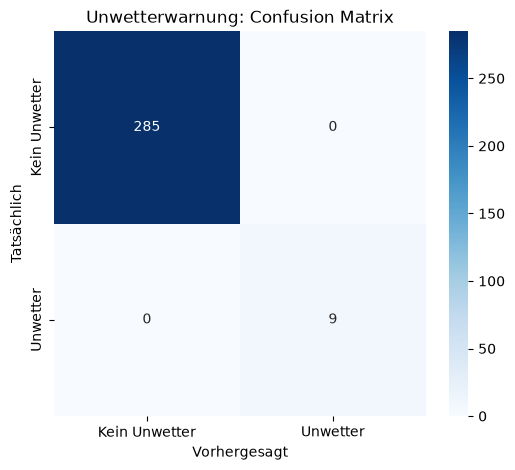

In [19]:
# Modell evaluieren
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Vorhersagen
y_true = y_test[label_column].astype(int).to_numpy()
y_pred = model.predict(X_test).astype(int)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("📋 Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=["Kein Unwetter", "Unwetter"],
    zero_division=0,
))

f1 = f1_score(y_true, y_pred, zero_division=0)
if np.unique(y_true).size == 2:
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    print(f"🎯 ROC-AUC: {roc_auc:.4f}")
else:
    roc_auc = float("nan")
    print("⚠️ ROC-AUC nicht berechnet: Im Testset ist nur eine Klasse vorhanden.")

print(f"🎯 F1-Score: {f1:.4f}")

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Unwetter", "Unwetter"],
    yticklabels=["Kein Unwetter", "Unwetter"],
)
plt.title("Unwetterwarnung: Confusion Matrix")
plt.ylabel("Tatsächlich")
plt.xlabel("Vorhergesagt")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

🏆 Top 10 wichtigste Features:
                   feature  importance
18      pressure_change_3h    0.712226
9    precip_rolling_sum_3h    0.276343
10   precip_rolling_sum_6h    0.004444
11  precip_rolling_sum_12h    0.002845
2            precipitation    0.002202
20       wind_gust_anomaly    0.000752
15        pressure_mean_3h    0.000692
1     relative_humidity_2m    0.000495
3             pressure_msl    0.000000
0           temperature_2m    0.000000


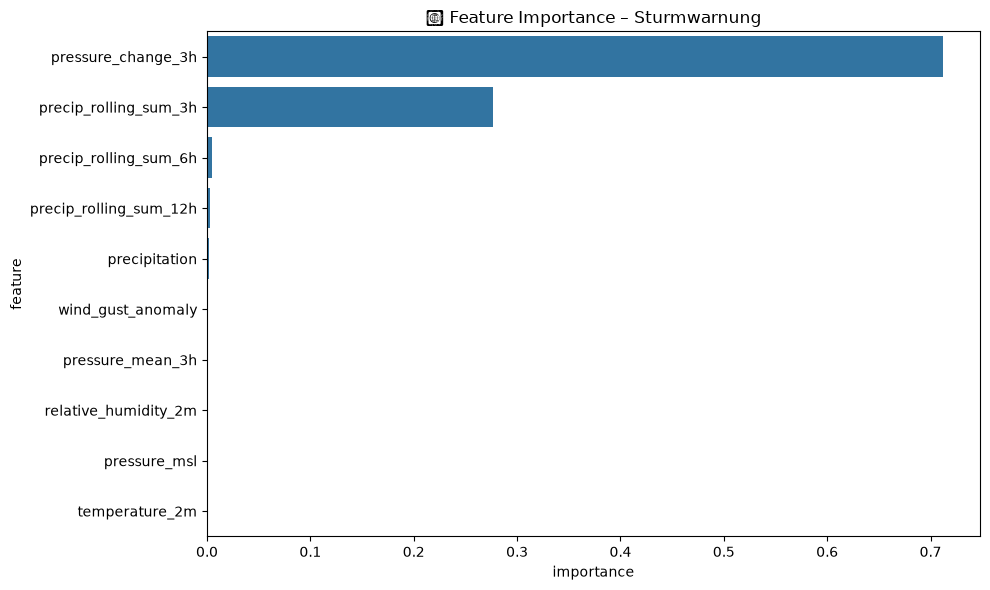

In [20]:
# Feature Importance
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("🏆 Top 10 wichtigste Features:")
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="importance", y="feature")
plt.title("🌟 Feature Importance – Sturmwarnung")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# Modell speichern und Metriken für die Model Registry vorbereiten
import json
import joblib
import math
import os

model_dir = "severe_weather_model"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "model.joblib")
joblib.dump(model, model_path)
print(f"✅ Modell lokal gespeichert: {model_path}")

metrics = {
    "f1_score": float(f1),
    "n_train_samples": int(len(X_train)),
    "n_test_samples": int(len(X_test)),
    "positive_class_ratio": float(y_train[label_column].mean()),
}

if math.isfinite(float(roc_auc)):
    metrics["roc_auc"] = float(roc_auc)
else:
    print("⚠️ ROC-AUC wird nicht registriert, weil sie nicht definiert ist.")

with open(os.path.join(model_dir, "metrics.json"), "w") as metrics_file:
    json.dump(metrics, metrics_file, indent=2, allow_nan=False)

print(f"📊 Metriken gespeichert: {metrics}")

✅ Modell lokal gespeichert: severe_weather_model/model.joblib
📊 Metriken gespeichert: {'f1_score': 1.0, 'n_train_samples': 1172, 'n_test_samples': 294, 'positive_class_ratio': 0.02901023890784983, 'roc_auc': 1.0}


In [22]:
# Upload in Hopsworks Model Registry
from hsml.schema import Schema
from hsml.model_schema import ModelSchema

# Model Registry abrufen
mr = project.get_model_registry()

# Input/Output Schema definieren (für Dokumentation & Validation)
input_schema = Schema(X_train)
output_schema = Schema(y_train[[label_column]])
model_schema = ModelSchema(input_schema=input_schema, output_schema=output_schema)

# Model-Objekt in Registry erstellen
severe_weather_model = mr.python.create_model(
    name="severe_weather_classifier",
    metrics=metrics,
    model_schema=model_schema,
    input_example=X_train.sample(1),
    description="XGBoost-Modell zur Unwetterwarnung basierend auf Open-Meteo Wetterdaten "
                 "(Wind, Niederschlag, Luftdruck-Trends)",
    feature_view=feature_view  # 🔗 Lineage zur Feature View
)

# Modell-Verzeichnis hochladen
severe_weather_model.save(model_dir)

print(f"Modell in Registry hochgeladen!")
print(f"Name: {severe_weather_model.name}")
print(f"Version: {severe_weather_model.version}")
print(f"Model ID: {severe_weather_model.id}")

  0%|          | 0/6 [00:00<?, ?it/s]

Moving model files from 'severe_weather_model' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.


Uploading /workspaces/fhnw_cas_aiops_project1_weather_forcasts/Trainings Pipeline/severe_weather_model/model.j…

Uploading /workspaces/fhnw_cas_aiops_project1_weather_forcasts/Trainings Pipeline/severe_weather_model/metrics…

Uploading /tmp/tmphn6qinwo/input_example.json: 0.000%|          | 0/276 elapsed<00:00 remaining<?

Uploading /tmp/tmphn6qinwo/model_schema.json: 0.000%|          | 0/1924 elapsed<00:00 remaining<?

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/44167/models/severe_weather_classifier/14
Modell in Registry hochgeladen!
Name: severe_weather_classifier
Version: 14
Model ID: severe_weather_classifier_14
